In [1]:
import pandas as pd
import numpy as np
import importlib
import jenkspy

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
# from scipy.conftest import xp_available_backends
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.stats import differential_entropy

import utility_functions as uf

In [2]:
year = 2022

mode = "individual"

In [17]:
df_prob_global = (
    pd.read_csv(uf.PATH+f"df_stats_subfields_global_yearly.csv")
    .query("year == @year")
    [["subfield_id", f"probability_{mode}"]]
    .rename(columns={f"probability_{mode}": "probability"})
    .set_index("subfield_id")
)

In [25]:
df_cs = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}_{year}.csv", index_col=0)
df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)
df_prob.columns = df_prob.columns.astype(int)

In [26]:
df_prob_global.index

Index([1100, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 1110,
       ...
       3603, 3604, 3605, 3607, 3608, 3609, 3611, 3612, 3614, 3616],
      dtype='int64', name='subfield_id', length=252)

In [27]:
df_prob.columns

Index([1100, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 1110,
       ...
       3603, 3604, 3605, 3607, 3608, 3609, 3611, 3612, 3614, 3616],
      dtype='int64', length=252)

In [29]:
df_im = np.log(
    df_prob
    .div(df_prob_global.probability, axis=1)
)
df_im

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
country,,,,,,,,,,,,,,,,,,,,,
AD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE,-1.584215,-2.447336,NaN,-0.962503,-2.210017,-0.306088,NaN,NaN,-1.026134,-0.486460,...,0.751773,0.434976,0.456008,0.241898,NaN,-0.750103,0.219679,-0.150043,0.427506,-0.311872
AF,0.605708,0.148052,0.342796,NaN,NaN,-0.846194,NaN,NaN,NaN,-0.311440,...,NaN,0.545457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.072109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AL,0.472177,NaN,NaN,-0.292406,-0.441307,-0.574260,1.031027,NaN,0.454893,0.248176,...,NaN,-0.281221,0.027493,NaN,NaN,NaN,NaN,0.232372,0.809921,0.946011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,2.785233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE,0.345177,NaN,NaN,1.372354,NaN,-0.008113,NaN,NaN,1.531866,-0.859653,...,NaN,0.284926,0.593640,NaN,NaN,1.179289,NaN,NaN,0.682921,0.413547
ZA,-0.030231,0.205260,0.400005,-0.373600,0.879297,-0.034280,0.544368,NaN,0.373699,0.422915,...,-0.451083,0.410775,0.351764,1.053945,1.192994,0.028043,0.050896,-1.774113,0.935063,0.277031


In [33]:
df_dist = uf.get_cosine_distances(df_im.fillna(0)) / 2
np.fill_diagonal(df_dist.values, np.nan)

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


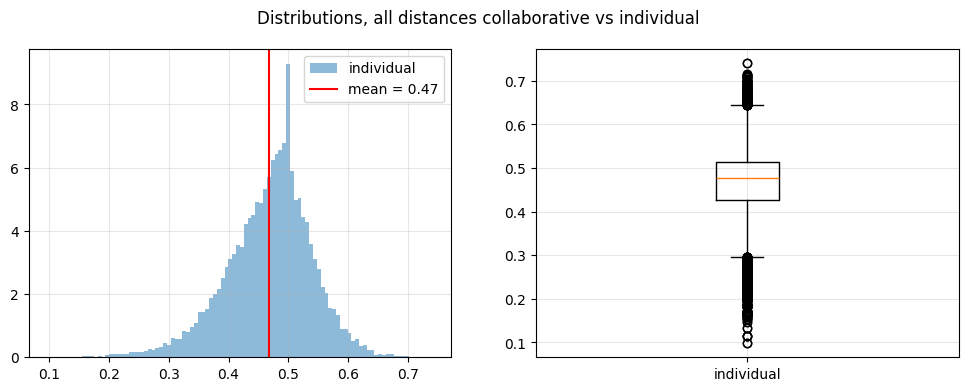

In [34]:
fig, (ax1, ax2) =plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

data1 = df_dist.values.flatten()
data1 = data1[~np.isnan(data1)]

ax1.hist(data1, bins=100, alpha=0.5, label=mode, density=True)
ax1.axvline(data1.mean(), color="red", label=f"mean = {round(data1.mean(), 2)}")
ax1.legend()
ax1.grid(alpha=0.3)
# plt.show()

plt.subplot(1, 2, 2)

ax2.boxplot([data1])
ax2.set_xticks([1], [mode])
ax2.grid(alpha=0.3)

plt.suptitle("Distributions, all distances collaborative vs individual")
plt.show()

In [35]:
np.quantile(data1, [0.05, 0.25, 0.5, 0.75, 0.95])

array([0.34106152, 0.4265225 , 0.47624281, 0.51346395, 0.57531245])

In [36]:
df_dist

country,AD,AE,AF,AG,AL,AM,AO,AR,AT,AU,...,VE,VG,VI,VN,VU,WS,YE,ZA,ZM,ZW
country,,,,,,,,,,,,,,,,,,,,,
AD,NaN,0.580161,0.491602,0.501317,0.448333,0.476717,0.458115,0.456574,0.478390,0.480090,...,0.432907,0.500000,0.494979,0.602432,0.500000,0.463692,0.499584,0.520846,0.497543,0.514933
AE,0.580161,NaN,0.495385,0.558825,0.463461,0.458735,0.535675,0.549359,0.444496,0.441213,...,0.481855,0.505625,0.537081,0.296136,0.510176,0.584460,0.479542,0.385142,0.442509,0.438587
AF,0.491602,0.495385,NaN,0.413987,0.317841,0.453776,0.440951,0.492209,0.563127,0.488205,...,0.372419,0.469108,0.484969,0.514871,0.513452,0.429712,0.328668,0.498070,0.326083,0.378182
AG,0.501317,0.558825,0.413987,NaN,0.478099,0.565626,0.445014,0.604146,0.567649,0.428616,...,0.507266,0.497881,0.463170,0.642992,0.425943,0.484551,0.456649,0.598889,0.453876,0.562757
AL,0.448333,0.463461,0.317841,0.478099,NaN,0.376749,0.369854,0.421079,0.452809,0.470257,...,0.343124,0.550017,0.475052,0.532901,0.537904,0.462770,0.362733,0.448359,0.290122,0.325700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,0.463692,0.584460,0.429712,0.484551,0.462770,0.523508,0.409095,0.442726,0.518042,0.490815,...,0.462945,0.422613,0.441955,0.524290,0.429062,NaN,0.488957,0.433729,0.474562,0.429693
YE,0.499584,0.479542,0.328668,0.456649,0.362733,0.410938,0.448830,0.492978,0.525549,0.518865,...,0.413204,0.545345,0.477755,0.434140,0.503466,0.488957,NaN,0.493599,0.371216,0.432511
ZA,0.520846,0.385142,0.498070,0.598889,0.448359,0.469167,0.410567,0.299710,0.477385,0.332618,...,0.351981,0.540771,0.463283,0.379359,0.480497,0.433729,0.493599,NaN,0.320472,0.283623


In [37]:
# y_labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()
# # y_labels = df_dist.index.to_list()
# uf.plotly_heatmap(
#     df_dist.loc[y_labels, y_labels],
#     x_labels=y_labels,
#     y_labels=y_labels,
#     z_min=0, z_max=1,
#     colorscale="non-symmetrical",
#     x_type="country",
#     y_type="country",
#     title=f"Distance between countries, {mode}, {year}",
# )

# Random clusterisation test

In [38]:
D = df_dist.fillna(0).values
# D = np.atan(3*df_dist.fillna(0).values)

In [39]:
# plt.hist(df_dist.values.flatten(), alpha=0.5)
# plt.hist(np.atan(3*df_dist.values.flatten()), alpha=0.5)

In [45]:
Z = linkage(df_im.fillna(0).values, method='average', metric='cosine')
labels1 = fcluster(Z, t=0.2, criterion='distance')

# For silhouette, pass raw data + metric
score = silhouette_score(df_im.fillna(0).values, labels1, metric='cosine')
score

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


np.float64(0.0023840277634421124)

In [ ]:
condensed_D = squareform(D)

Z = linkage(condensed_D, method='average')

labels1 = fcluster(Z, t=0.2, criterion='distance')

score = silhouette_score(D, labels1, metric="precomputed")
score

In [49]:
condensed_D = squareform(D)

Z = linkage(condensed_D, method='average')

labels1 = fcluster(Z, t=0.2, criterion='distance')

score = silhouette_score(D, labels1, metric="precomputed")
score

np.float64(0.02881814483670933)

In [51]:
from sklearn.cluster import AgglomerativeClustering

X = df_im.fillna(0).values

model = AgglomerativeClustering(n_clusters=10, metric='cosine', linkage='average')

labels = model.fit_predict(X)

score = silhouette_score(X, labels, metric="cosine")
score

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


np.float64(0.084287527855333)

In [41]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=10, metric='precomputed', linkage='average')

labels = model.fit_predict(D)

score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(0.084287527855333)

In [ ]:
from sklearn.cluster import DBSCAN
condensed_D = squareform(D)
model = DBSCAN(eps=0.1, min_samples=2, metric='precomputed')
labels = model.fit_predict(D)
score = silhouette_score(D, labels, metric="precomputed")
score

ValueError: Expected 2D array, got 1D array instead:
array=[0.5801614  0.4916023  0.50131678 ... 0.32047223 0.28362254 0.21829115].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [43]:
from sklearn.cluster import OPTICS

model = OPTICS(metric='precomputed', min_samples=2, max_eps=0.2)
labels = model.fit_predict(D)
score = silhouette_score(D, labels, metric="precomputed")
score

np.float64(-0.10266591657642542)

In [44]:
from sklearn.cluster import SpectralClustering
import numpy as np

# Convert distance -> similarity
sigma = 0.01
affinity = np.exp(-D**2 / (2 * sigma**2))

model = SpectralClustering(n_clusters=5, affinity='precomputed')
labels = model.fit_predict(affinity)
score = silhouette_score(D, labels, metric="precomputed")
score

/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:79: RuntimeWarning: divide by zero encountered in matmul
  np.matmul(x, y, out=x)
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:79: RuntimeWarning: overflow encountered in matmul
  np.matmul(x, y, out=x)
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:79: RuntimeWarning: invalid value encountered in matmul
  np.matmul(x, y, out=x)
/Users/irinavorobeva/Library/Python/3.9/lib/python/site-packages/scipy/sparse/linalg/_eigen/lobpcg/lobpcg.py:66: RuntimeWarning: divide by zero encountered in matmul
  return lambda v: m @ v
/Users/irinavorobeva/Library

np.float64(-0.04882616869354862)

In [172]:
# fig = go.Figure(
#     data=go.Heatmap(
#         z=D_ordered,
#         x=names_ordered,
#         y=names_ordered,
#         colorscale="Viridis",
#         colorbar=dict(title="Distance"),
#         hovertemplate="Row: %{y}<br>Col: %{x}<br>Dist: %{z:.3f}<extra></extra>"
#     )
# )
#
# fig.update_layout(
#     title="Distance matrix reordered by cluster labels",
#     xaxis=dict(
#         tickangle=45,
#         tickfont=dict(size=8),
#         automargin=True
#     ),
#     yaxis=dict(
#         tickfont=dict(size=8),
#         automargin=True
#     ),
#     width=900,
#     height=900
# )
# # cluster boundaries
# changes = np.where(np.diff(labels_ordered) != 0)[0] + 1
#
# for c in changes:
#     fig.add_shape(
#         type="line",
#         x0=-0.5, x1=len(names_ordered)-0.5,
#         y0=c-0.5, y1=c-0.5,
#         line=dict(color="white", width=1)
#     )
#     fig.add_shape(
#         type="line",
#         x0=c-0.5, x1=c-0.5,
#         y0=-0.5, y1=len(names_ordered)-0.5,
#         line=dict(color="white", width=1)
#     )
#
# fig.show()


In [ ]:
df_map = (
    df_dist
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "region", "sub-region"]], left_index=True, right_on="alpha-2", how="left")
    [["alpha-2", "alpha-3", "name", "sub-region", "region"]]
    .assign(cluster=labels,
            cluster_str = lambda df: df["cluster"].astype(str))
    .rename(columns={"alpha-3": "country3", "alpha-2": "country"})
    # .merge(pd.read_csv(uf.PATH+"df_country_stats_yearly.csv").query("year == @year and mode == @mode").drop(["year", "mode"], axis=1),
    #        left_on="country", right_on="country", how="left")

)
df_map.sample(5)

,country,country3,name,sub-region,region,cluster,cluster_str
45,CN,CHN,China,Eastern Asia,Asia,-1,-1
72,FK,FLK,Falkland Islands (Malvinas),Latin America and the Caribbean,Americas,6,6
181,RE,REU,Réunion,Sub-Saharan Africa,Africa,0,0
83,DE,DEU,Germany,Western Europe,Europe,0,0
70,SZ,SWZ,Eswatini,Sub-Saharan Africa,Africa,0,0


In [174]:
df_cluster_subfields = (
    df_cs
    .merge(df_map[["country", "cluster_str"]], left_index=True, right_on="country", how="left")
    .drop("country", axis=1)
    .groupby("cluster_str")
    .sum()
)
df_cluster_prob = df_cluster_subfields.div(df_cluster_subfields.sum(axis=1), axis=0)

In [175]:
df_dist_clusters = uf.get_w1_distances(subfield_tree, df_cluster_prob)

In [176]:
# df_dist_clusters

In [177]:
# labels = df_map.groupby("cluster_str").country.count().sort_values(ascending=False).head(10).index.to_list()
# uf.plotly_heatmap(df_dist_clusters.loc[labels, labels], x_labels=labels, y_labels=labels, colorscale="non", line_height=20)

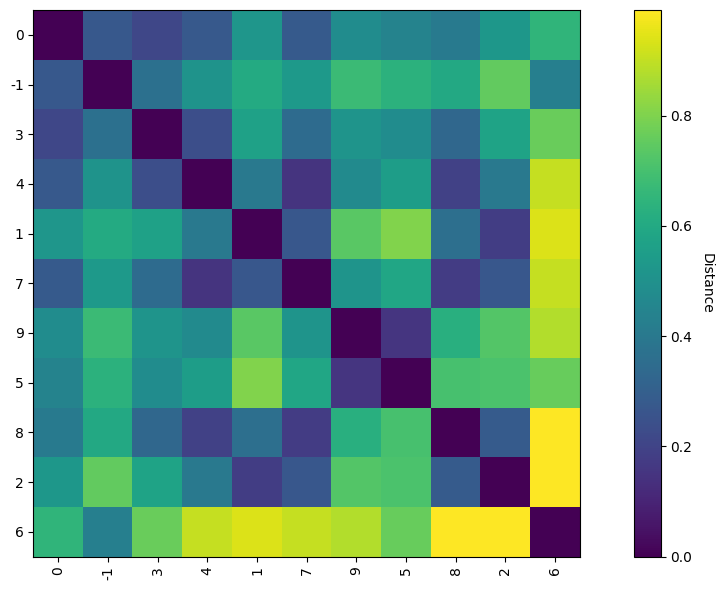

In [178]:
labels = df_cluster_prob.apply(uf.gini, axis=1).sort_values(ascending=True).index.to_list()

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(df_dist_clusters.loc[labels, labels].values, cmap='viridis')

# Set y-ticks
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)

# Optionally, set x-ticks similarly
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90)

# Add colorbar for distance interpretation
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Distance', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

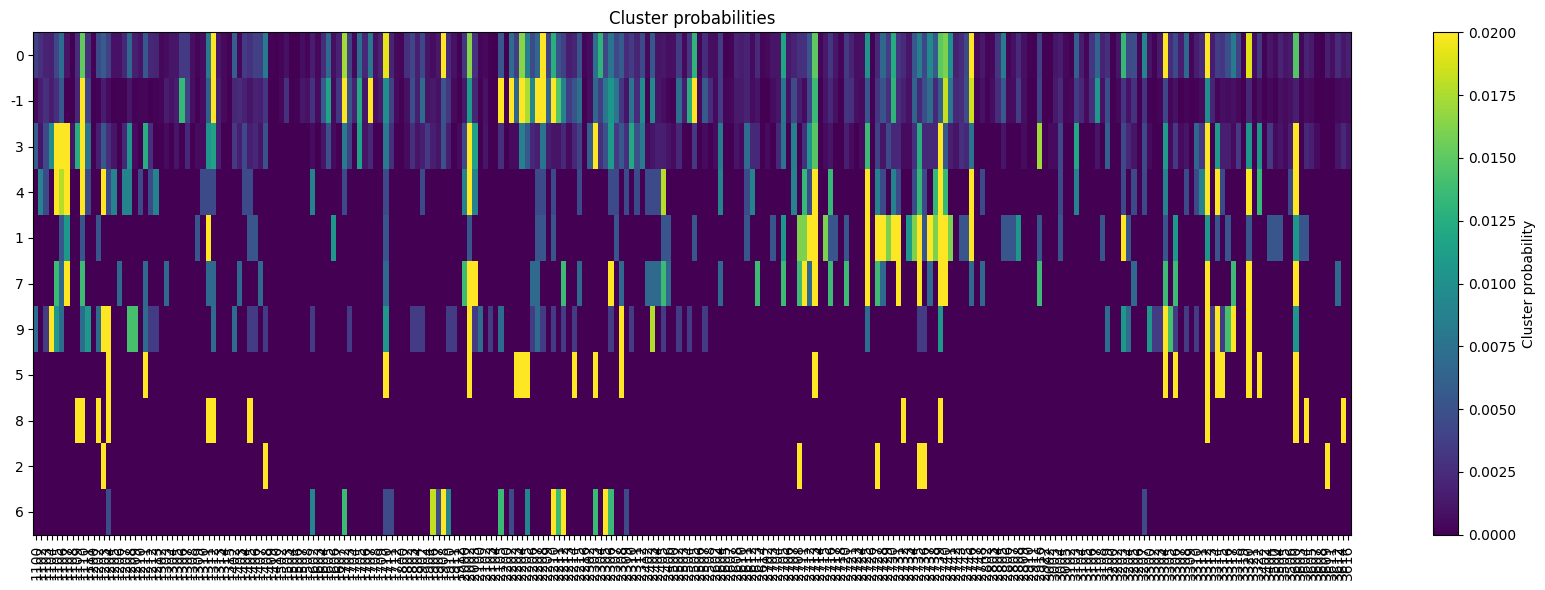

In [179]:
fig, ax = plt.subplots(figsize=(17, 6))

x_values = df_cluster_prob.columns.to_list()
y_values = df_map.groupby("cluster_str").country.count().sort_values(ascending=False).index.to_list()
y_values = df_cluster_prob.apply(uf.gini, axis=1).sort_values(ascending=True).index.to_list()

# Set vmax to 0.02 to normalize colors
im = ax.imshow(df_cluster_prob.loc[y_values].values, cmap='viridis', vmin=0, vmax=0.02, aspect='auto')

# Set y-ticks
ax.set_yticks(np.arange(len(y_values)))
ax.set_yticklabels(y_values)

# Optionally, set x-ticks similarly
ax.set_xticks(np.arange(len(x_values)))
ax.set_xticklabels(x_values, rotation=90)

# Add colorbar to interpret distances/probabilities
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Cluster probability')

# Title
ax.set_title("Cluster probabilities")

plt.tight_layout()
plt.show()

In [180]:
# x_values = df_cluster_prob.columns
# y_values = df_cluster_prob.index
# uf.plotly_heatmap(df_cluster_prob.loc[labels, x_values], x_values, labels, x_type="subfield", colorscale="non", z_min=0, z_max=0.02)

(<Figure size 1200x600 with 2 Axes>, <Axes: title={'center': ' '}>)

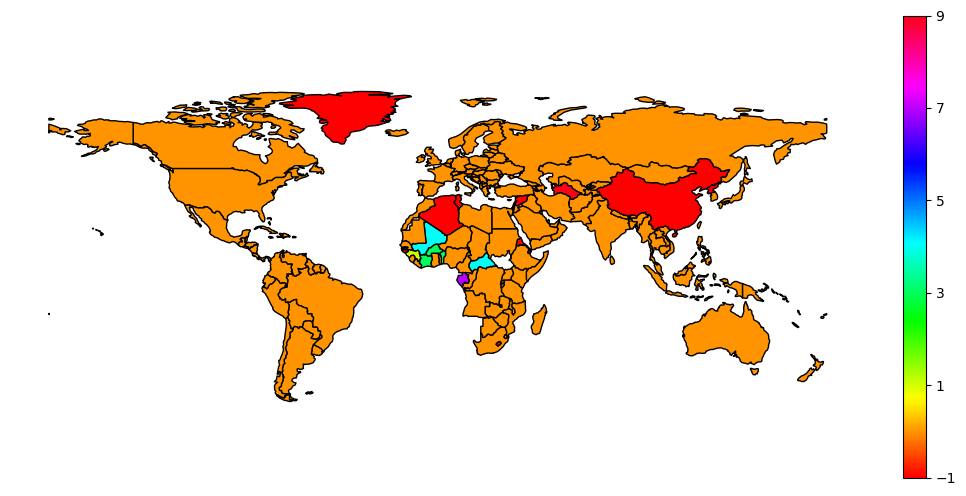

In [181]:
uf.plot_map_continuous(df_map, "cluster", country_column="country3")

In [41]:
# fig = px.choropleth(
#     df_map,
#     locations="country3",
#     color="cluster_str",               # use the categorical version
#     locationmode="ISO-3",
#     color_discrete_sequence=px.colors.qualitative.Set3,  # discrete color palette
#     title=f"Country clusters based on distance matrix, {mode}, {year}"
# )
# #
# fig.update_layout(
#     geo=dict(
#         showframe=False,
#         showcoastlines=True,
#         projection_type="natural earth"
#     ),
#     height=600,
# )
#
# fig.show()

# UMAP 2D

In [ ]:
import umap
import numpy as np

np.random.sample(3)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.01,
    metric="precomputed"
)

embedding = reducer.fit_transform(df_dist.fillna(0).values)
df_embedding = (
    pd.DataFrame(embedding, index=df_dist.index, columns=["dim1", "dim2"])
    .reset_index(names="country")
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "sub-region", "region"]], left_on="country", right_on="alpha-2", how="left")
    .merge(pd.read_csv(uf.PATH+"df_country_stats_yearly.csv").query("year == @year and mode == @mode").drop(["year", "mode"], axis=1),
           left_on="country", right_on="country", how="left")
    .assign(
        n_close=((df_dist < 0.1).sum(axis=1)).values,
        mean_dist=(df_dist.mean(axis=1)).values,
        median_dist=(df_dist.median(axis=1)).values,
    )
)

In [ ]:
px.histogram(df_embedding, x=["mean_dist", "median_dist"], nbins=50, barmode="overlay")

In [ ]:
df_embedding

In [ ]:
px.scatter(df_embedding, x="dim1", y="dim2", hover_data="name", color="n_close",)


In [ ]:
uf.plot_map_continuous(df_embedding, "n_close")

In [ ]:
uf.plot_map_continuous(df_embedding, "median_dist", range=(0, 0.5))

# Mean dist categorisation

In [ ]:
df_dist

In [ ]:
df_plot = df_dist.max(axis=1).to_frame("mean_dist").merge(
    uf.df_country[["alpha-2", "alpha-3"]],
    left_index=True,
    right_on="alpha-2",
    how="left",
)

In [ ]:
(
    df_dist.mean(axis=1).to_frame("mean_dist").merge(
        uf.df_country[["alpha-2", "alpha-3"]],
        left_index=True,
        right_on="alpha-2",
        how="left",
    )
    .assign(
        min_dist=df_dist.min(axis=1).values,
        max_dist=df_dist.max(axis=1).values,
        q01_dist=df_dist.quantile(0.01, axis=1).values,
        q09_dist=df_dist.quantile(0.09, axis=1).values,
        cat_mean=lambda df: pd.cut(df["mean_dist"], bins=jenkspy.jenks_breaks(df.mean_dist, 6), include_lowest=True, labels=False),
        cat_min=lambda df: pd.cut(df["min_dist"], bins=jenkspy.jenks_breaks(df.min_dist, 6), include_lowest=True, labels=False),
        cat_max=lambda df: pd.cut(df["max_dist"], bins=jenkspy.jenks_breaks(df.max_dist, 6), include_lowest=True, labels=False),
        cat_q01=lambda df: pd.cut(df["q01_dist"], bins=jenkspy.jenks_breaks(df.q01_dist, 6), include_lowest=True, labels=False),
        cat_q09=lambda df: pd.cut(df["q09_dist"], bins=jenkspy.jenks_breaks(df.q09_dist, 6), include_lowest=True, labels=False)
    )
)

In [ ]:
breaks_list = jenkspy.jenks_breaks(df_plot.mean_dist, 6)
plt.hist(df_plot.mean_dist, bins=50)
for break_ in breaks_list:
    plt.axvline(break_, color="red")
plt.grid()
plt.show()

In [ ]:
df_plot = (
    df_plot
    .assign(category=pd.cut(df_plot["mean_dist"], bins=jenkspy.jenks_breaks(df_plot.mean_dist, 6), include_lowest=True, labels=False)
    )
)

In [ ]:
uf.plot_map_continuous(df_plot, "category", title="Mean dist categorised (Fisher)")

# Field level

In [ ]:
£